Image 1 keypoints: 200
Image 2 keypoints: 200
Good matches after ratio test: 13
Matches displayed: 13


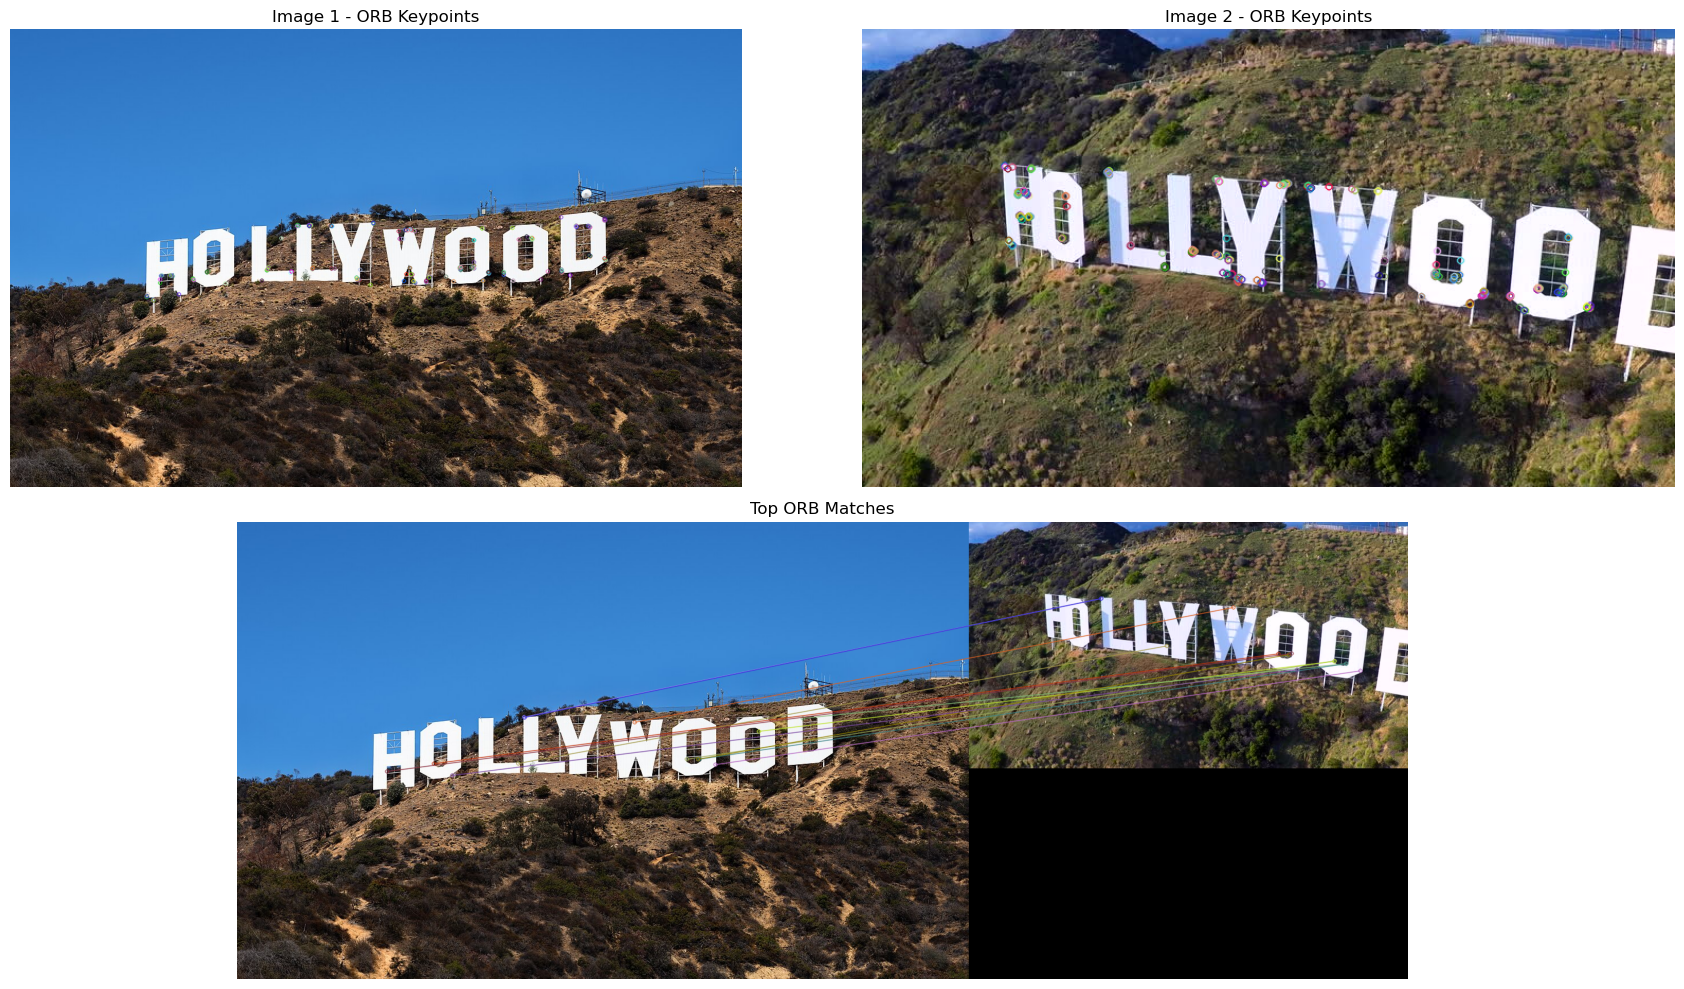


Top match distances:
Match 1: distance = 19.0
Match 2: distance = 26.0
Match 3: distance = 29.0
Match 4: distance = 29.0
Match 5: distance = 33.0
Match 6: distance = 33.0
Match 7: distance = 34.0
Match 8: distance = 40.0
Match 9: distance = 40.0
Match 10: distance = 41.0


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1_path = "h1.jpg"
img2_path = "h2.jpg"

img1_bgr = cv2.imread(img1_path)
img2_bgr = cv2.imread(img2_path)

img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

gray1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(
    nfeatures=200,    
    scaleFactor=1.2,
    nlevels=8,
    edgeThreshold=31,
    patchSize=31,
    fastThreshold=20
)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print(f"Image 1 keypoints: {len(kp1)}")
print(f"Image 2 keypoints: {len(kp2)}")

img1_kp = cv2.drawKeypoints(
    img1_rgb, kp1, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT
)

img2_kp = cv2.drawKeypoints(
    img2_rgb, kp2, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT
)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
knn_matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
ratio = 0.75

for pair in knn_matches:
    if len(pair) == 2:
        m, n = pair
        if m.distance < ratio * n.distance:
            good_matches.append(m)
            
#best distance matches 
good_matches = sorted(good_matches, key=lambda x: x.distance)

print(f"Good matches after ratio test: {len(good_matches)}")

top_n = 30
good_matches = good_matches[:top_n]

print(f"Matches displayed: {len(good_matches)}")

matched_img = cv2.drawMatches(
    img1_rgb, kp1,
    img2_rgb, kp2,
    good_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
plt.imshow(img1_kp)
plt.title("Image 1 - ORB Keypoints")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img2_kp)
plt.title("Image 2 - ORB Keypoints")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.imshow(matched_img)
plt.title("Top ORB Matches")
plt.axis("off")

plt.tight_layout()
plt.show()

# match distances 
print("\nTop match distances:")
for i, m in enumerate(good_matches[:10]):
    print(f"Match {i+1}: distance = {m.distance}")